---
authors: Naren Ramakrishnan
  - name: Naren Ramakrishnan
    affiliation: University of Washington
    email: narenpr@uw.edu
    github: https://github.com/NarenRamakrishnan
    linkedin: www.linkedin.com/in/naren-ramakrishnan
---

# Machine Learning Techniques for Flood Extent Detection

**TODO**: The goal of this project is to apply Machine Learning to SAR-based flood extent data to identify regions most prone to flooding and possibly even predict when floodings can occur (may be too complex to be done in the project). Using the NASA Flood Extent Detection dataset, I will explore how ML can enhance flood risk assessment and contribute to early warning systems that save lives and minimize damage.The research questions I aim to explore are listed below.

**Research questions**:

1. How can historical SAR-based flood extent data be used to identify recurring flood-prone regions?
   
    This research question investigates how patterns in historical flood data
    could be analyzed to identify regions that experience frequent flooding events
    over time.
   
2. How eﬀectively can past SAR-based flood extent data be used to identifyflood-prone areas and anticipate future flood events?

    This research question investigates the predictive potential of historical flood
    data alongside Machine Learning for predicting future flood risks.

3. How accurately can Machine Learning models detect flood extents from Sentinel-1 SAR imagery compared to existing baseline methods?

    This research question focuses on evaluating the performance of multiple
    Machine Learning models against existing methods for flood detection.

   
4. What image-processing or feature-extraction techniques yield the most accurate flood extent detection from SAR data?

    This research question examines which image-processing and preprocessing
    techniques contribute the most to improving the accuracy of flood detection
    models.

## Motivation

**TODO**: Floods are one of the most devasting natural disasters in the world today. Many have lost their lives due to the unpredictability of this disaster. Additionally, floods cause severe economical and environmental damage leaving entire cities devastated. Climate change continues to aEect weather patterns, and with the melting of the ice caps, the frequency and severity of floods are projected to increase. This urges the requirement development of flood prediction models to mitigate the impact of
future floods.

• Research question 1
At the base of this project is the identification of the most recurring flood-prone regions. Identifying the most recurring flood-prone regions could create a positive global impact, allowing fortification and therefore the reduction of lives lost.

• Research question 2
While this research question could be challenging to address as it would involve the combination of multiple datasets and complex machine learning techniques, if solved, it could massively reduce the number of lives lost to floods by providing accurate predictions of future flood events. This would allow the early evacuation of the residents of the region while also providing caution, allowing them to better fortify themselves against the flood.

• Research question 3
While this research question is similar to my first research question, it takes a more technical approach. As I am interested in Machine Learning, this research question would allow me to identify and compare multiple machine learning models against the existing baseline methods. My main motivation behind this research question is to explore multiple machine learning models and to learn more about ML, while also maintaining focus on flood detection.

• Research question 4
Like my third research question, this research would allow me to take a more technical approach to this problem, allowing me to explore various image-processing and feature-extraction techniques while also maintaining focus on creating a positive global impact through flood detection.

Having used Machine Learning for Autism detection, I have witnessed first-hand the positive social impact that Machine Learning can have in the world. I believe this project can make a tangible difference in how we respond to these disasters. By identifying flood-prone regions and recurring patterns, we can strengthen early warning systems, help communities better prepare, and save lives. Addressing these research questions could be a steppingstone to help inform more effective disaster management policies, guide infrastructure development in flood prone areas, and help us better understand how geographic factors influence flooding. I care about this problem because it represents the intersection of technology and humanitarian impact. Like my project with autism, this project can have a positive global impact by directly supporting eEorts to build safer and more resilient communities worldwide.

In [1]:
your_name = "Naren Pudupatty Ramakrishnan"
sources = [
    ...
]

assert your_name != "", "your_name cannot be empty"
assert ... not in sources, "sources should not include the placeholder ellipsis"
assert len(sources) >= 6, "must include at least 6 sources, inclusive of lectures and sections"

AssertionError: sources should not include the placeholder ellipsis

## Data Setting

**TODO**: 
To explore research question 2, additional data would be needed. Additionally, I may use other datasets to improve the accuracies of the models while also generalizing the predictions to address worldwide floods as opposed to only the regions
presented in the dataset.

The primary dataset I will be using for this project is the NASA Flood Extent Detection dataset. It contains information derived from Synthetic Aperture Radar (SAR) images captured during various flood events in the U.S and Bangladesh. The dataset was created by NASA-IMPACT collaborating with University of Alabama in Huntsville and includes 50000 (according to UC Irvine ML Repository) SAR images. The data was collected from the European Space Agency’s Sentinel-1A and Sentinel-1B missions. Each image relates to a specific flood event and is labeled to indicate if it represents a flooded or non-flooded region. The dataset is openly available for access on UC Irvine’s Machine Learning Repository: https://archive.ics.uci.edu/dataset/770/nasa+flood+extent+detection

A datasheet is available for this dataset providing detailed documentation about its
creation, labeling methodology, and intended application. Considering the context
of this dataset, the following are some limitations which may complicate the
analysis:

1. The dataset does not contain data worldwide, covering only events in the U.S. and Bangladesh. This may reduce the model’s generalizability to other regions with diEerent terrain or flooding patterns.

2. There may be some noise in the data. This would aEect the flood detection accuracy and would thus require preprocessing the data to filter it out before model training to ensure maximum accuracy.

3. There may be errors in labelling. While the dataset was reviewed by Flood domain experts and provided to Earth science students for labeling, there may be errors in labeling due to limitations in human interpretation. This could introduce noise into model training.
 
Though these limitations exist, these challenges can be mitigated through preprocessing and augmenting the data by also including other relevant datasets or through synthetic data augmentation.

In [1]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse

In [ ]:
'''I wrote this code to extract all the files from the dataset because there was no way to download
it all once from the dataset without having to individually download every file. I wont be 
downloading the dataset in jupyter lab because it takes up a lot of space 
(4.55 GB for just one dataset), but I have added a few folders in the 'data' folder showing 
example data from the dataset. This also skipped folders with the same name as they were 
an error on my part while copying the folder names.
'''

flood_names=['bangladesh_20170314t115609',
'bangladesh_20170606t115613',
'bangladesh_20170712t115615',
'florence_20180510t231343',
'florence_20180522t231344',
'florence_20180603t231344',
'florence_20180615t231345',
'florence_20180709t231346',
'florence_20180721t231347',
'florence_20180802t231348',
'florence_20180907t231350',
'florence_20180919t231350',
'florence_20181001t231350',
'nebraska_20170108t002112',
'nebraska_20170213t002121',
'nebraska_20170309t002110',
'nebraska_20170402t002111',
'nebraska_20170508t002113',
'nebraska_20170520t002113',
'nebraska_20170601t002114',
'nebraska_20170402t002111',
'nebraska_20170508t002113',
'nebraska_20170520t002113',
'nebraska_20170601t002114',
'nebraska_20170929t002120',
'nebraska_20171116t002120',
'nebraska_20171210t002119',
'nebraska_20171222t002118',
'northal_20190302t234651',
'northal_20190407t234651',
'northal_20190419t234652',
'northal_20190513t234653',
'northal_20190525t234653',
'northal_20190606t234654',
'northal_20190618t234654',
'northal_20190630t234655',
'northal_20190724t234657',
'northal_20190805t234658',
'northal_20190829t234659',
'northal_20190910t234659',
'northal_20191004t234700',
'northal_20191121t234700',
'northal_20191227t234659',
'redrivernorth_20190104t002247',
'redrivernorth_20190116t002247',
'redrivernorth_20190128t002246',
'redrivernorth_20190209t002246',
'redrivernorth_20190221t002246',
'redrivernorth_20190317t002246',
'redrivernorth_20190410t002246',
'redrivernorth_20190422t002247',
'redrivernorth_20190504t002247',
'redrivernorth_20190516t002248',
'redrivernorth_20190528t002248',
'redrivernorth_20190609t002249',
'redrivernorth_20190621t002250']

def get_file_links(url):
    r=requests.get(url)
    r.raise_for_status()
    soup=BeautifulSoup(r.text, "html.parser")
    file_links=[]
    for a in soup.find_all("a", href=True):
        href=urljoin(url, a["href"])
        if any(href.endswith(ext) for ext in [".tif", ".png", ".msk", ".zip"]):
            href=href.replace("staging.source.coop", "data.source.coop")
            file_links.append(href)
    return file_links

def download_file(url, folder):
    file_name=os.path.basename(urlparse(url).path)
    path=os.path.join(folder, file_name)
    os.makedirs(os.path.dirname(path), exist_ok=True)  
    if os.path.exists(path):
        return
    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            with open(path, "wb") as f:
                for chunk in r.iter_content(8192):
                    f.write(chunk)

def download_all_files(folder_url, download_dir):
    file_links=get_file_links(folder_url)
    for link in file_links:
        download_file(link, download_dir)

if __name__ == "__main__":
    base_url="https://staging.source.coop/nasa/floods"
    base_dir="data" # I changed the base_dir so it would work with this jupyter
    # notebook as well

    for flood_name in flood_names:
        folder_path=os.path.join(base_dir, flood_name)
        os.makedirs(folder_path, exist_ok=True)
        folder_url=f"{base_url}/{flood_name}"
        download_all_files(folder_url, folder_path)

## Method

**TODO**: 

**• Step 1: Data Loading and Conversion**:
This is a data-manipulation function that involves loading the SAR images from the dataset and converting them into NumPy arrays for processing. I can test this function on a few images from the dataset to ensure the arrays are of the correct shape. This step helps prepare the raw SAR data for preprocessing, analysis and modeling.

**• Step 2: Preprocessing**:
This is a data-manipulation function that involves reducing noise, handling missing and corrupted data, resizing images to a consistent shape, and performing data augmentation. I can test this function on a few images from the dataset and manually check
the output to see if it fits the appropriate specifications. This ensures the model receives clean and consistent inputs connecting to the Messy Data challenge goal.

**• Step 3: Train/Test/Validate Split**:
This is a data-manipulation function that involves splitting the dataset into train, validation, and test sets. I can test this by ensuring there is an appropriate split of images with no duplicates across splits.

**• Step 4: Modeling Training and Evaluation**:
This is a data-manipulation function that involves training multiple Machine Learning models with systematic hyperparameter tuning and then evaluating them using accuracy, precision, recall, and F1-score on the validations set. I can test this by first running the function on a smaller sized dataset to ensure training completes without errors and the metrics are reflected. This also directly address research question 3 and 4 by allowing the comparison of model performance for flood detection.

**• Step 5: Visualization**:
This is a plotting function that involves creating visual comparisons between the model’s predicted flood areas versus the actual flood regions from the dataset. These visualizations can help understand the model’s accuracy and where it may make mistakes, connecting to research question 3 and 4.

**• Step 6: Integration with Multiple Datasets**:
This is a step which is applicable only to the first and second research questions. This is a data-manipulation technique that involves joining the SAR flood data along with complementary datasets to improve the analysis of recurring flood patterns, and the prediction of flood-prone regions. I can test this by checking that the merged datasets include no missing or duplicated entries.

**• Step 7: Conclusions**:
This is the final step and involves interpreting the results to address the research question. The analysis will involve finding the regions that are most frequently affected by flooding, how effectively SAR data can predict flood-prone areas, and which Machine Learning models perform the best for this task.

## EDA Results

**TODO**: *Replace this text with a summary of your findings from the EDA.*

1. *What steps did you take during your EDA that prepared the work you conducted for the rest of your analysis?*
1. *What did you learn about your data from doing the EDA?*
1. *How did your understanding of the data setting change?*

In [ ]:
base_dir="data"
total=0
flood_names=os.listdir(base_dir)
for flood in flood_names:
    folder_path=os.path.join(base_dir,flood)
    if not os.path.isdir(folder_path):
        continue
    files=os.listdir(folder_path)
    total+=len(files)
print(f"total number of files:{total}")
print(f"total number of folders:{len(flood_names)}")


**How large is your dataset?**

Since I haven't uploaded all my data on this notebook, I ran this code locally, on VS code, and attached a picture of the result below.
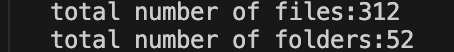

But not all of the files from every folder are needed.

**What is the data and what does it show?**

In [6]:
base_dir="data/bangladesh_20170314t115609"
os.listdir(base_dir)

['bangladesh_img_news1a_iw_rt30_20170314t115609_g_gpf_vv.tif',
 'bangladesh_img_news1a_iw_rt30_20170314t115609_g_gpf_vv.tif.msk',
 'bangladesh_img_news1a_iw_rt30_20170314t115609_g_gpf_vh.tif.msk',
 'bangladesh_20170314t115609_label.tif',
 'bangladesh_img_news1a_iw_rt30_20170314t115609_g_gpf_vh.tif',
 'bangladesh_20170314t115609_label.png']

These are the different types of files within the folder 'bangladesh_20170314t115609'. The names of the folder are based on the location and the timestamp of the SAR-image. The 'bangladesh_img_news1a_iw_rt30_20170314t115609_g_gpf_vv.tif' file 'vv' to generalize and the 'bangladesh_img_news1a_iw_rt30_20170314t115609_g_gpf_vh.tif' 'vh' to generalize (these type of files (vv and vh) exist in every folder in the dataset) are the inputs to the model. 

SAR sends and recieves microwave signals to view Earth. vv refers vertical-vertical polarization and vh refers to vertical-horizontal polarization. Polarization refers to the direction of the radar wave (uses microwave signals). v refers to the electric field of wave being vertical while h refers to the elctric field of wave being horizontal. vv refers to when radar sends a vertical wave and recieves a vertical wave while vh refers to when radar sends a vertical wave but recieves a horizontal wave. Using both vv and vh helps build a better image of the land, vv highlights water, while vh highlights vegetation or rough surfaces. However, I am not fully sure if this is accurate, this was based on my research.

The target labels or the output of the model are stored in the bangladesh_20170314t115609_label.tif or to generalize, label.tif files. These files include an 8-bit integer for every value, however each pixel can only take on 3 different values:
255 which refers to when theres water(flooded)
0 when there is no water(land)
and 15 when there is no data due to errors in data collection. The 'bangladesh_20170314t115609_label.png' or 'label.png' files to generalize help to visalize the same data that is represented in the label.tif files.

The .msk files are masked files which include binary data for every pixel. 1 refers to a valid pixel while 0 refers to a pixel with no data. These files are used to identify which pixels have no data but can be ignored or used as an auxiliary as the label.tif files show the same.

In essence only the vv and vh files are used as input, and the label.tif files are used as the target values. If the model runs into errors, I may use the masked files to tell it which pixels to ignore or use the png files to possibly improve accuracy.

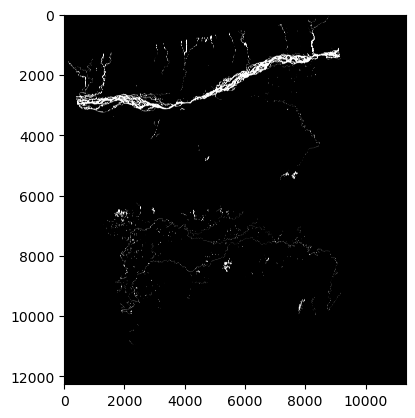

In [11]:
"""
This shows an example of the .png files for visualization. 
"""

import imageio.v3 as iio
import matplotlib.pyplot as plt
plt.imshow(iio.imread("data/bangladesh_20170314t115609/bangladesh_20170314t115609_label.png"),cmap="gray")

**Does your dataset have any missing data?**

Yes the data has missing values as mentioned, represented by the pixels in the label.tif files with a value of 15.

In [15]:
!conda install -c conda-forge gdal -y


Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.5.0
    latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [14]:
import os
from osgeo import gdal
import numpy as np

root_dir = "data"
total_pixels=0
num_no_data=0

for dirpath, dirnames, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename.endswith("_label.tif"):
            filepath = os.path.join(dirpath, filename)
            ds = gdal.Open(filepath)
            label = ds.GetRasterBand(1).ReadAsArray()
            num_no_data += np.sum(label == 15)
            total_pixels += label.size

print(f"The total percent of pixels in all the label.tif files with no data is {num_no_data/total_pixels *100}")


ModuleNotFoundError: No module named 'osgeo'

I ran this code locally as all my data is stored and got the following output:
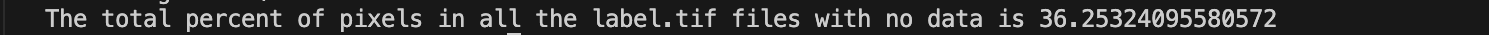
Luckily as I am working with SAR-based data, I can simply filter out the pixels with a value of 15 during model training and prevent the model from looking at this pixels while allowing it to also look at the entire file.

**What are the variables of interest for your research questions?**

The variables of interest for my research questions are, the pixels with values 0 and 255 in the label.tif files and the corresponding pixels in the vv and vh files. As I have expanded on what these variables are in the **What is the data and what does it show?** section I won't be doing it here.

These variables help focus on research question 1 and 3 as it would allow me to identify recurring flood-prone regions from SAR-based data and would also allow me to compare the accuracy of the model I run against existing methods.

**Give a summary of each variable of interest.**

I am not too sure how to give a summary of the vv and vh files so I will be giving a summary of the pixels (15-No data, 255-Water, 0-land) in the label.tif files.

In [13]:
import os
from osgeo import gdal
import numpy as np

root_dir = "data"
total_pixels=0
num_no_data=0
num_flood_data=0
num_land_data=0

for dirpath, dirnames, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename.endswith("_label.tif"):
            filepath = os.path.join(dirpath, filename)
            ds = gdal.Open(filepath)
            label = ds.GetRasterBand(1).ReadAsArray()
            num_no_data += np.sum(label == 15)
            num_flood_data += np.sum(label == 255)
            num_land_data += np.sum(label == 0)
            total_pixels += label.size

print(f"total pixels:{total_pixels }")
print(f"total pixels with no data:{num_no_data}")
print(f"total pixels with data as water(flood):{num_flood_data}")
print(f"total pixels with data as land:{num_land_data}")


ModuleNotFoundError: No module named 'osgeo'

Running this code locally I got


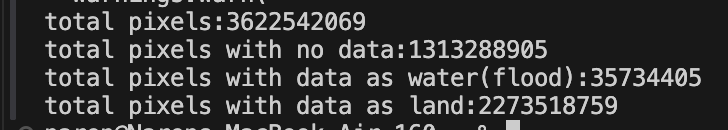

But these just look like big numbers so to get a better idea of the amount of data of each category, I will write it as a percentage of the total data.


In [18]:
total_pixels=3622542069
no_data=1313288905
data_water=35734405
data_land=2273518759
print(f"Percentage of pixels with no data:{no_data/total_pixels *100}%")
print(f"Percentage of pixels with water data:{data_water/total_pixels *100}%")
print(f"Percentage of pixels with land data:{data_land/total_pixels *100}%")

Percentage of pixels with no data:36.25324095580572%
Percentage of pixels with water data:0.9864455489916355%
Percentage of pixels with land data:62.760313495202645%


## Results

**TODO**: *Replace this text with your results. Be sure to create new code cells and new Markdown text cells with additional subheadings to explain and break-up longer snippets of code into a more readable format.*

1. *Present and discuss your research results. Treat each of your research questions separately. Include additional discussions for results that are most interesting, surprising, or important. Discuss the consequences or implications.*
2. *Interpret the results. If the answers are unexpected, try to offer an explanation. A good report not only presents the results, but provides an argument or interpretation based on the data analysis.*
3. *Include any visualizations you have made. In general, these should be generated programmatically as part of your project code.*

*Documentation and testing are required. Automated tests must be written in Python using small, manually-verifiable data sets. Automated tests can be written here alongside results (best for doctests or assertion statements that help the reader understand the code), or appended to the bottom of this notebook (best for more comprehensive testing that could interfere with readability).*

## Implications and Limitations

**TODO**: *Replace this text with your discussion of the broader implications and limitations of your results.*

1. *Who might benefit from your analysis, who might be excluded, and who might be harmed by it?*
1. *How did the data setting impact your results?*
1. *Explain at least 3 limitations of your analysis and how others should use your conclusions.*

## Challenge Goals

**TODO**: *Replace this text with your challenge goals. If the challenge goals were scaled back or expanded, explain why the task turned out differently than initially estimated.*

## Plan Evaluation

**TODO**: *Replace this text with an evaluation of your proposed work plan. How accurate were your proposed work plan estimates? Why were your estimates close to reality or far from reality?*

## Testing

**TODO**: *Replace this text with a description of your testing. How did you use doctests and/or assertions? Smaller data files? Visualizations? Make sure you tell us why we should trust your results!*